In [1]:

!pip install kaggle
from google.colab import files
files.upload()

# Setup Kaggle credentials
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download dataset
!kaggle datasets download -d velavansekar/adni-mri-alzheimer-dataset-train-val-test-split

# Unzip
!unzip adni-mri-alzheimer-dataset-train-val-test-split.zip

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/velavansekar/adni-mri-alzheimer-dataset-train-val-test-split
License(s): unknown
100% 13.6G/13.6G [02:13<00:00, 110MB/s]

Archive:  adni-mri-alzheimer-dataset-train-val-test-split.zip
  inflating: test/test/AD/002_S_1018_MPRAGE_SENSE_20061218145444_301.nii  
  inflating: test/test/AD/011_S_0010_MPRAGE_20051107080954_2a.nii  
  inflating: test/test/AD/011_S_0010_MPRAGE_20071107120857_2.nii  
  inflating: test/test/AD/011_S_0010_MPRAGE_20071107120857_2a.nii  
  inflating: test/test/AD/011_S_0053_MPRAGE_20051114084826_3.nii  
  inflating: test/test/AD/011_S_0053_MPRAGE_20071129121454_2a.nii  
  inflating: test/test/AD/011_S_0183_MPRAGE_20060303120239_2.nii  
  inflating: test/test/AD/011_S_0183_MPRAGE_20070403115534_2a.nii  
  inflating: test/test/AD/011_S_0183_MPRAGE_20070403115534_5.nii  
  inflating: test/test/

In [4]:
import os

base_path = "/content"

train_path = os.path.join(base_path, "train", "train")
val_path   = os.path.join(base_path, "val", "val")
test_path  = os.path.join(base_path, "test", "test")

print("Train classes:", os.listdir(train_path))
print("Val classes:", os.listdir(val_path))
print("Test classes:", os.listdir(test_path))

Train classes: ['MCI', 'AD', 'CN']
Val classes: ['MCI', 'AD', 'CN']
Test classes: ['MCI', 'AD', 'CN']


In [5]:
!pip install nibabel

import nibabel as nib
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

CHECK SIZE

In [13]:
# pick one class
class_name = os.listdir(train_path)[0]
class_path = os.path.join(train_path, class_name)

# pick one file
file_name = os.listdir(class_path)[0]
file_path = os.path.join(class_path, file_name)

print("Sample file:", file_path)

# load NIfTI
img = nib.load(file_path)
data = img.get_fdata()

print("Original shape:", data.shape)

Sample file: /content/train/train/MCI/023_S_0613_MPRAGE_20060621120228_2.nii
Original shape: (160, 192, 192)


VISUALISE SLICES


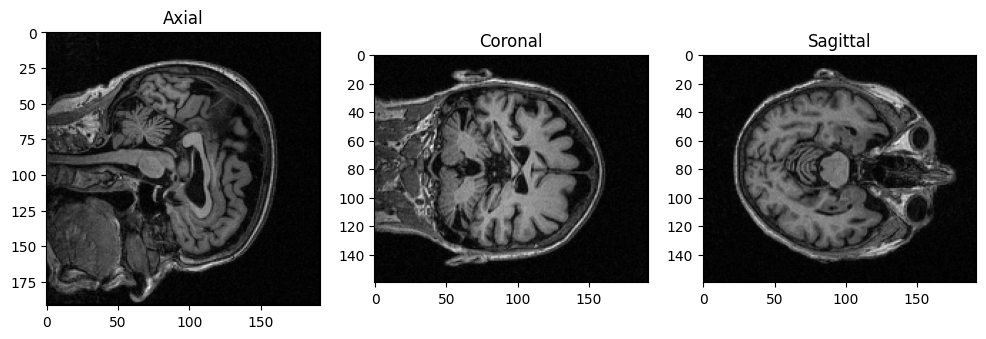

In [14]:
# show middle slices
mid = data.shape[0] // 2

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(data[mid,:,:], cmap='gray')
plt.title("Axial")

plt.subplot(1,3,2)
plt.imshow(data[:,mid,:], cmap='gray')
plt.title("Coronal")

plt.subplot(1,3,3)
plt.imshow(data[:,:,mid], cmap='gray')
plt.title("Sagittal")

plt.show()

CONVERTING TO TENSOR AND RESIZING


In [15]:
import numpy as np
import torch
import torch.nn.functional as F
import tensorflow as tf

# data = numpy array from nibabel (shape: D,H,W)

print("Original shape:", data.shape)

# normalize
data = (data - np.mean(data)) / (np.std(data) + 1e-8)

# convert to torch tensor
data_torch = torch.tensor(data, dtype=torch.float32)

# add batch + channel → (1,1,D,H,W)
data_torch = data_torch.unsqueeze(0).unsqueeze(0)

# resize to (64,64,64)
data_torch = F.interpolate(
    data_torch,
    size=(64, 64, 64),
    mode='trilinear',
    align_corners=False
)

print("After resize:", data_torch.shape)

# remove batch+channel → (64,64,64)
data_np = data_torch.squeeze().numpy()

# convert to TensorFlow format → (64,64,64,1)
data = tf.convert_to_tensor(data_np, dtype=tf.float32)
data = tf.expand_dims(data, axis=-1)

# add batch → (1,64,64,64,1)
data = tf.expand_dims(data, axis=0)

print("Final shape:", data.shape)

Original shape: (160, 192, 192)
After resize: torch.Size([1, 1, 64, 64, 64])
Final shape: (1, 64, 64, 64, 1)


In [16]:
import os
import nibabel as nib
import numpy as np

# paths (from earlier fix)
train_path = "/content/train/train"

classes = os.listdir(train_path)
label_map = {cls: i for i, cls in enumerate(classes)}

print("Classes:", label_map)

Classes: {'MCI': 0, 'AD': 1, 'CN': 2}


In [17]:
import torch
import torch.nn.functional as F

def load_mri(file_path):
    img = nib.load(file_path)
    data = img.get_fdata()

    # normalize
    data = (data - np.mean(data)) / (np.std(data) + 1e-8)

    # torch resize
    data = torch.tensor(data, dtype=torch.float32)
    data = data.unsqueeze(0).unsqueeze(0)

    data = F.interpolate(data, size=(64,64,64), mode='trilinear', align_corners=False)

    data = data.squeeze().numpy()

    return data

In [19]:
X = []
y = []

max_samples_per_class =20  # keep small initially

for cls in classes:
    class_dir = os.path.join(train_path, cls)
    files = os.listdir(class_dir)[:max_samples_per_class]

    for file in files:
        file_path = os.path.join(class_dir, file)

        volume = load_mri(file_path)

        X.append(volume)
        y.append(label_map[cls])

print("Loaded samples:", len(X))

Loaded samples: 60


In [20]:
import tensorflow as tf

X = np.array(X)
y = np.array(y)

# add channel dimension → (N,64,64,64,1)
X = np.expand_dims(X, axis=-1)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (60, 64, 64, 64, 1)
y shape: (60,)


In [21]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [22]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Conv3D(16, 3, activation='relu', padding='same', input_shape=(64,64,64,1)),
    layers.MaxPooling3D(2),

    layers.Conv3D(32, 3, activation='relu', padding='same'),
    layers.MaxPooling3D(2),

    layers.Conv3D(64, 3, activation='relu', padding='same'),
    layers.MaxPooling3D(2),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(3, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [23]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv3d (Conv3D)                 │ (None, 64, 64, 64, 16) │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d (MaxPooling3D)    │ (None, 32, 32, 32, 16) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_1 (Conv3D)               │ (None, 32, 32, 32, 32) │        13,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_1 (MaxPooling3D)  │ (None, 16, 16, 16, 32) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_2 (Conv3D)               │ (None, 16, 16, 16, 64) │        55,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_2 (MaxPooling3D)  │ (None, 8, 8, 8, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,264,483 (16.27 MB)

 Trainable params: 4,264,483 (16.27 MB)

 Non-trainable params: 0 (0.00 B)

In [24]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=5,
    batch_size=2
)

Epoch 1/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 46s 2s/step - accuracy: 0.3125 - loss: 1.5618 - val_accuracy: 0.1667 - val_loss: 1.1029
Epoch 2/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 44s 2s/step - accuracy: 0.3750 - loss: 1.0987 - val_accuracy: 0.1667 - val_loss: 1.1051
Epoch 3/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 45s 2s/step - accuracy: 0.3750 - loss: 1.0982 - val_accuracy: 0.1667 - val_loss: 1.1038
Epoch 4/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 43s 2s/step - accuracy: 0.3750 - loss: 1.0964 - val_accuracy: 0.1667 - val_loss: 1.1096
Epoch 5/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - accuracy: 0.3333 - loss: 1.0975 - val_accuracy: 0.1667 - val_loss: 1.1189


In [25]:
loss, acc = model.evaluate(X_val, y_val)
print("Validation Accuracy:", acc)

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.1667 - loss: 1.1189
Validation Accuracy: 0.1666666716337204


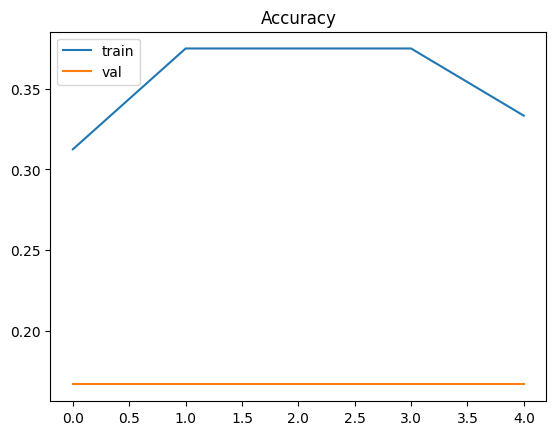

In [27]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.legend()
plt.title("Accuracy")
plt.show()

IMPROVING RESULTS

In [29]:
# new experiment parameters
max_samples_per_class_new = 30
resize_dim = 32

In [30]:
def load_mri_small(file_path):
    img = nib.load(file_path)
    data = img.get_fdata()

    # normalize
    data = (data - np.mean(data)) / (np.std(data) + 1e-8)

    # torch resize
    data = torch.tensor(data, dtype=torch.float32)
    data = data.unsqueeze(0).unsqueeze(0)

    data = F.interpolate(
        data,
        size=(resize_dim, resize_dim, resize_dim),
        mode='trilinear',
        align_corners=False
    )

    return data.squeeze().numpy()

In [31]:
X_new = []
y_new = []

for cls in classes:
    class_dir = os.path.join(train_path, cls)
    files = os.listdir(class_dir)[:max_samples_per_class_new]

    for file in files:
        file_path = os.path.join(class_dir, file)

        volume = load_mri_small(file_path)

        X_new.append(volume)
        y_new.append(label_map[cls])

print("New dataset size:", len(X_new))

New dataset size: 90


In [32]:
from sklearn.utils import shuffle

X_new = np.array(X_new)
y_new = np.array(y_new)

# add channel
X_new = np.expand_dims(X_new, axis=-1)

# shuffle
X_new, y_new = shuffle(X_new, y_new, random_state=42)

print("X shape:", X_new.shape)

X shape: (90, 32, 32, 32, 1)


In [33]:
from sklearn.model_selection import train_test_split

X_train_new, X_val_new, y_train_new, y_val_new = train_test_split(
    X_new, y_new, test_size=0.2, random_state=42
)

USING SIMPLER MODEL DEFINITION

In [34]:
model_small = models.Sequential([
    layers.Conv3D(8, 3, activation='relu', padding='same', input_shape=(resize_dim,resize_dim,resize_dim,1)),
    layers.MaxPooling3D(2),

    layers.Conv3D(16, 3, activation='relu', padding='same'),
    layers.MaxPooling3D(2),

    layers.Flatten(),

    layers.Dense(64, activation='relu'),
    layers.Dense(3, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [35]:
model_small.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [36]:
history_small = model_small.fit(
    X_train_new, y_train_new,
    validation_data=(X_val_new, y_val_new),
    epochs=10,
    batch_size=2
)

Epoch 1/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 7s 162ms/step - accuracy: 0.4306 - loss: 1.4466 - val_accuracy: 0.2222 - val_loss: 1.1183
Epoch 2/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 6s 171ms/step - accuracy: 0.3611 - loss: 1.0900 - val_accuracy: 0.2222 - val_loss: 1.1369
Epoch 3/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 5s 150ms/step - accuracy: 0.4583 - loss: 1.0755 - val_accuracy: 0.2222 - val_loss: 1.1051
Epoch 4/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 7s 189ms/step - accuracy: 0.6528 - loss: 1.0065 - val_accuracy: 0.3889 - val_loss: 1.1941
Epoch 5/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 5s 149ms/step - accuracy: 0.6667 - loss: 0.8691 - val_accuracy: 0.3889 - val_loss: 1.1989
Epoch 6/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 7s 182ms/step - accuracy: 0.7639 - loss: 0.6875 - val_accuracy: 0.3889 - val_loss: 1.5174
Epoch 7/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 6s 160ms/step - accuracy: 0.8333 - loss: 0.4374 - val_accuracy: 0.2222 - val_loss: 2.0093
Epoch 8/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 10s 141ms/step - accuracy: 0.9167 - loss: 0.2696 - val_accuracy: 0

In [37]:
loss_new, acc_new = model_small.evaluate(X_val_new, y_val_new)

print("Improved Validation Accuracy:", acc_new)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 515ms/step - accuracy: 0.2222 - loss: 1.8984
Improved Validation Accuracy: 0.2222222238779068


In [38]:
test_path = "/content/test/test"

X_test_new = []
y_test_new = []

for cls in classes:
    class_dir = os.path.join(test_path, cls)
    files = os.listdir(class_dir)[:10]

    for file in files:
        file_path = os.path.join(class_dir, file)

        volume = load_mri_small(file_path)

        X_test_new.append(volume)
        y_test_new.append(label_map[cls])

X_test_new = np.array(X_test_new)
y_test_new = np.array(y_test_new)

X_test_new = np.expand_dims(X_test_new, axis=-1)

loss_test, acc_test = model_small.evaluate(X_test_new, y_test_new)

print("Test Accuracy:", acc_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 588ms/step - accuracy: 0.4667 - loss: 1.5268
Test Accuracy: 0.46666666865348816


In [40]:
print("EXPERIMENT COMPARISON")
print("Initial Validation Accuracy: ~0.16")
print("Improved Validation Accuracy:", acc_new)
print("Test Accuracy:", acc_test)

EXPERIMENT COMPARISON
Initial Validation Accuracy: ~0.16
Improved Validation Accuracy: 0.2222222238779068
Test Accuracy: 0.46666666865348816


TRYING TO IMPROVE FURTHER USING DROPOUT AND BATCHNORM

In [41]:
model_better = models.Sequential([
    layers.Conv3D(8, 3, padding='same', input_shape=(resize_dim,resize_dim,resize_dim,1)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling3D(2),

    layers.Conv3D(16, 3, padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling3D(2),

    layers.Conv3D(32, 3, padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling3D(2),

    layers.Flatten(),

    layers.Dense(128),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.4),

    layers.Dense(3, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [42]:
model_better.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [43]:
history_better = model_better.fit(
    X_train_new, y_train_new,
    validation_data=(X_val_new, y_val_new),
    epochs=15,
    batch_size=2
)

Epoch 1/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 11s 182ms/step - accuracy: 0.2500 - loss: 1.4542 - val_accuracy: 0.3889 - val_loss: 1.0681
Epoch 2/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 7s 207ms/step - accuracy: 0.3889 - loss: 1.2146 - val_accuracy: 0.3889 - val_loss: 1.0307
Epoch 3/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 6s 176ms/step - accuracy: 0.4444 - loss: 1.1490 - val_accuracy: 0.4444 - val_loss: 1.0258
Epoch 4/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 11s 189ms/step - accuracy: 0.3056 - loss: 1.2755 - val_accuracy: 0.4444 - val_loss: 1.0866
Epoch 5/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 7s 206ms/step - accuracy: 0.4861 - loss: 1.1145 - val_accuracy: 0.4444 - val_loss: 1.1571
Epoch 6/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 9s 179ms/step - accuracy: 0.4306 - loss: 1.2825 - val_accuracy: 0.3889 - val_loss: 1.5068
Epoch 7/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 9s 239ms/step - accuracy: 0.5417 - loss: 1.0717 - val_accuracy: 0.3333 - val_loss: 1.2120
Epoch 8/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 6s 178ms/step - accuracy: 0.5972 - loss: 0.9492 - val_accuracy: 

In [44]:
loss_better, acc_better = model_better.evaluate(X_val_new, y_val_new)

print("Better Model Validation Accuracy:", acc_better)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.3889 - loss: 2.5575
Better Model Validation Accuracy: 0.3888888955116272


In [45]:
loss_test_better, acc_test_better = model_better.evaluate(X_test_new, y_test_new)

print("Better Model Test Accuracy:", acc_test_better)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.3667 - loss: 2.4696
Better Model Test Accuracy: 0.36666667461395264


In [47]:
print("FINAL COMPARISON")
print("Initial Model: ~0.16")
print("Improved Model:", acc_new)
print("Test Accuracy:", acc_test)
print("Better Model:", acc_better)
print("Better Model Test:", acc_test_better)

FINAL COMPARISON
Initial Model: ~0.16
Improved Model: 0.2222222238779068
Test Accuracy: 0.46666666865348816
Better Model: 0.3888888955116272
Better Model Test: 0.36666667461395264


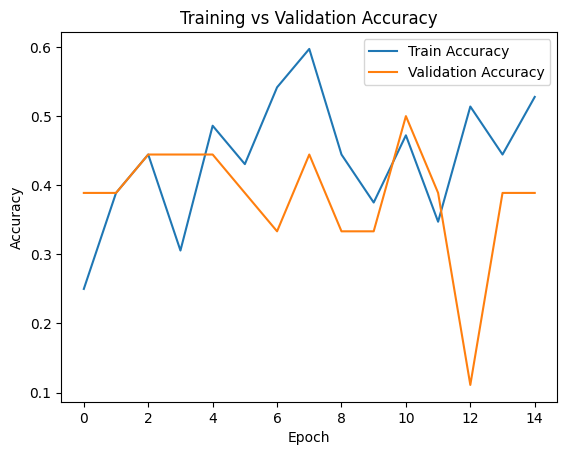

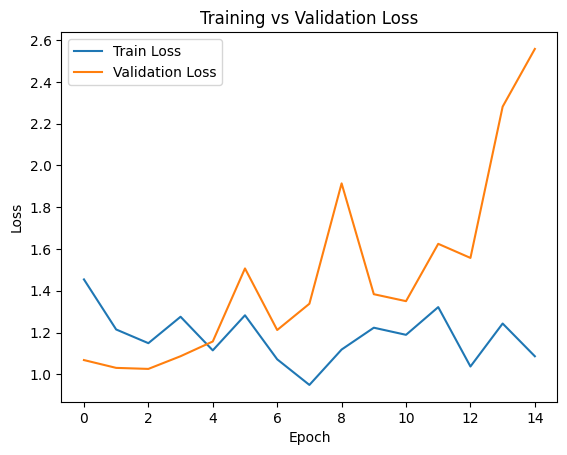

In [48]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure()
plt.plot(history_better.history['accuracy'], label='Train Accuracy')
plt.plot(history_better.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()

# Loss
plt.figure()
plt.plot(history_better.history['loss'], label='Train Loss')
plt.plot(history_better.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

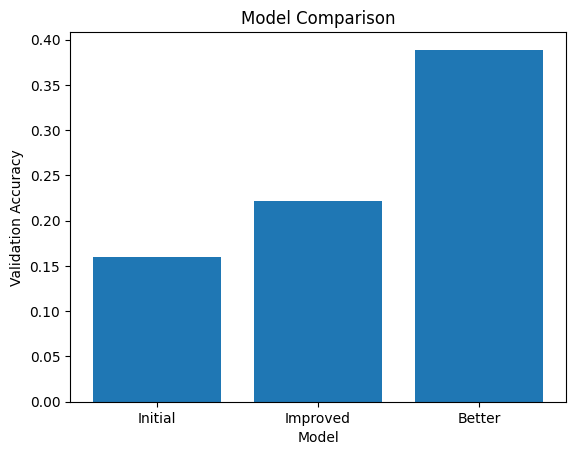

In [49]:
import matplotlib.pyplot as plt

models_names = ['Initial', 'Improved', 'Better']
val_accuracies = [0.16, acc_new, acc_better]

plt.figure()
plt.bar(models_names, val_accuracies)
plt.xlabel('Model')
plt.ylabel('Validation Accuracy')
plt.title('Model Comparison')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


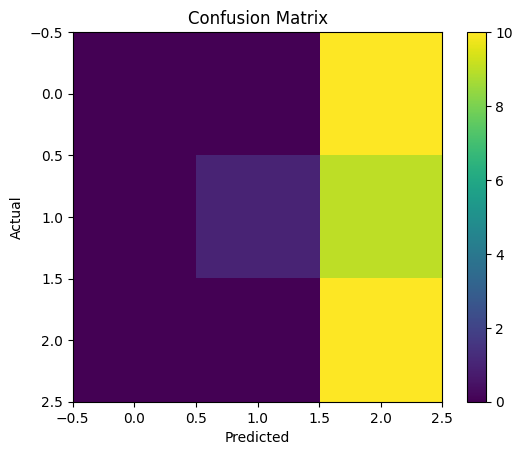

In [50]:
from sklearn.metrics import confusion_matrix
import numpy as np
import matplotlib.pyplot as plt

# Predictions
y_pred = model_better.predict(X_test_new)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test_new, y_pred_classes)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

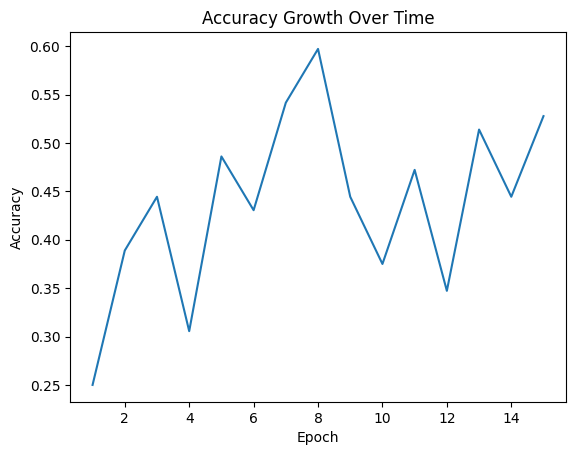

In [52]:
epochs = list(range(1, len(history_better.history['accuracy'])+1))

plt.figure()
plt.plot(epochs, history_better.history['accuracy'])
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Growth Over Time")
plt.show()